In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

In [2]:
from info_patterns.parameters import (SPHERE_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, DEFAULT_FARFIELD_PARAMS, DEFAULT_GAUSSIAN_FIELD_PARAMS, 
                            DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, 
                            DEFAULT_2D_FILL)
from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)
from info_patterns.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry, scattered_farfield_from_simulation, com_scattered_farfield)
from info_patterns.information_patterns_simulation import (info_patterns_from_scattered_field)
from info_patterns.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)
set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "com_sphere_results"

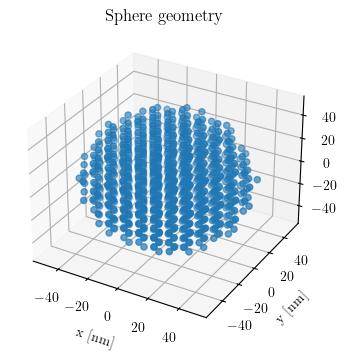

Geometry shape: (853, 3)
Geometry center: [ 0.0000000e+00  1.3706972e-06 -5.1813695e-05]
Material: <pyGDM2.materials.sio2 object at 0x12ad60410>


In [3]:
geometry = nanoparticle_geometry(**SPHERE_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Sphere geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)

In [4]:
farfield_params = DEFAULT_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]

efield = incident_field(**DEFAULT_GAUSSIAN_FIELD_PARAMS)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 2172.1ms, inv.: 344.8ms, repropa.: 414.9ms (1 field configs), tot: 2933.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 421.8ms, inv.: 606.5ms, repropa.: 23.2ms (1 field configs), tot: 1054.1ms


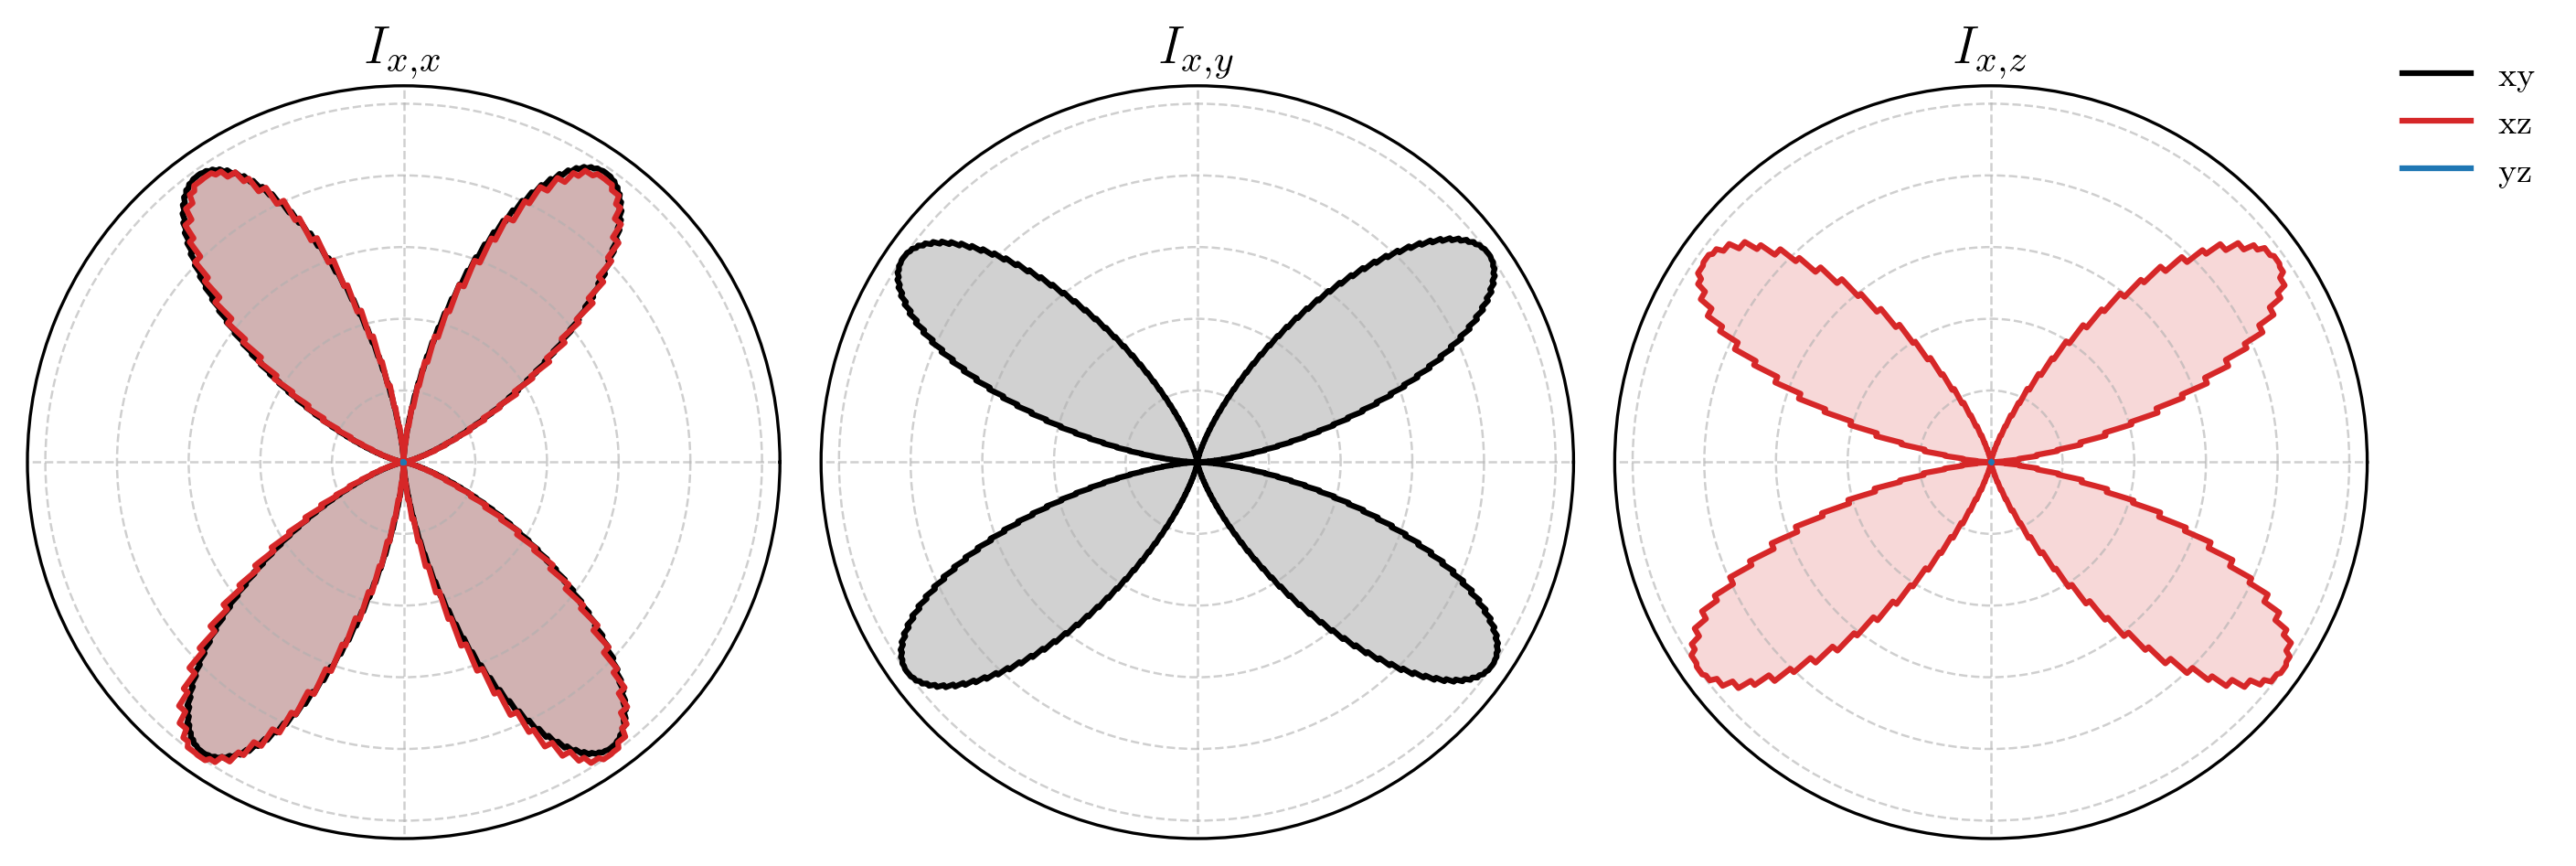

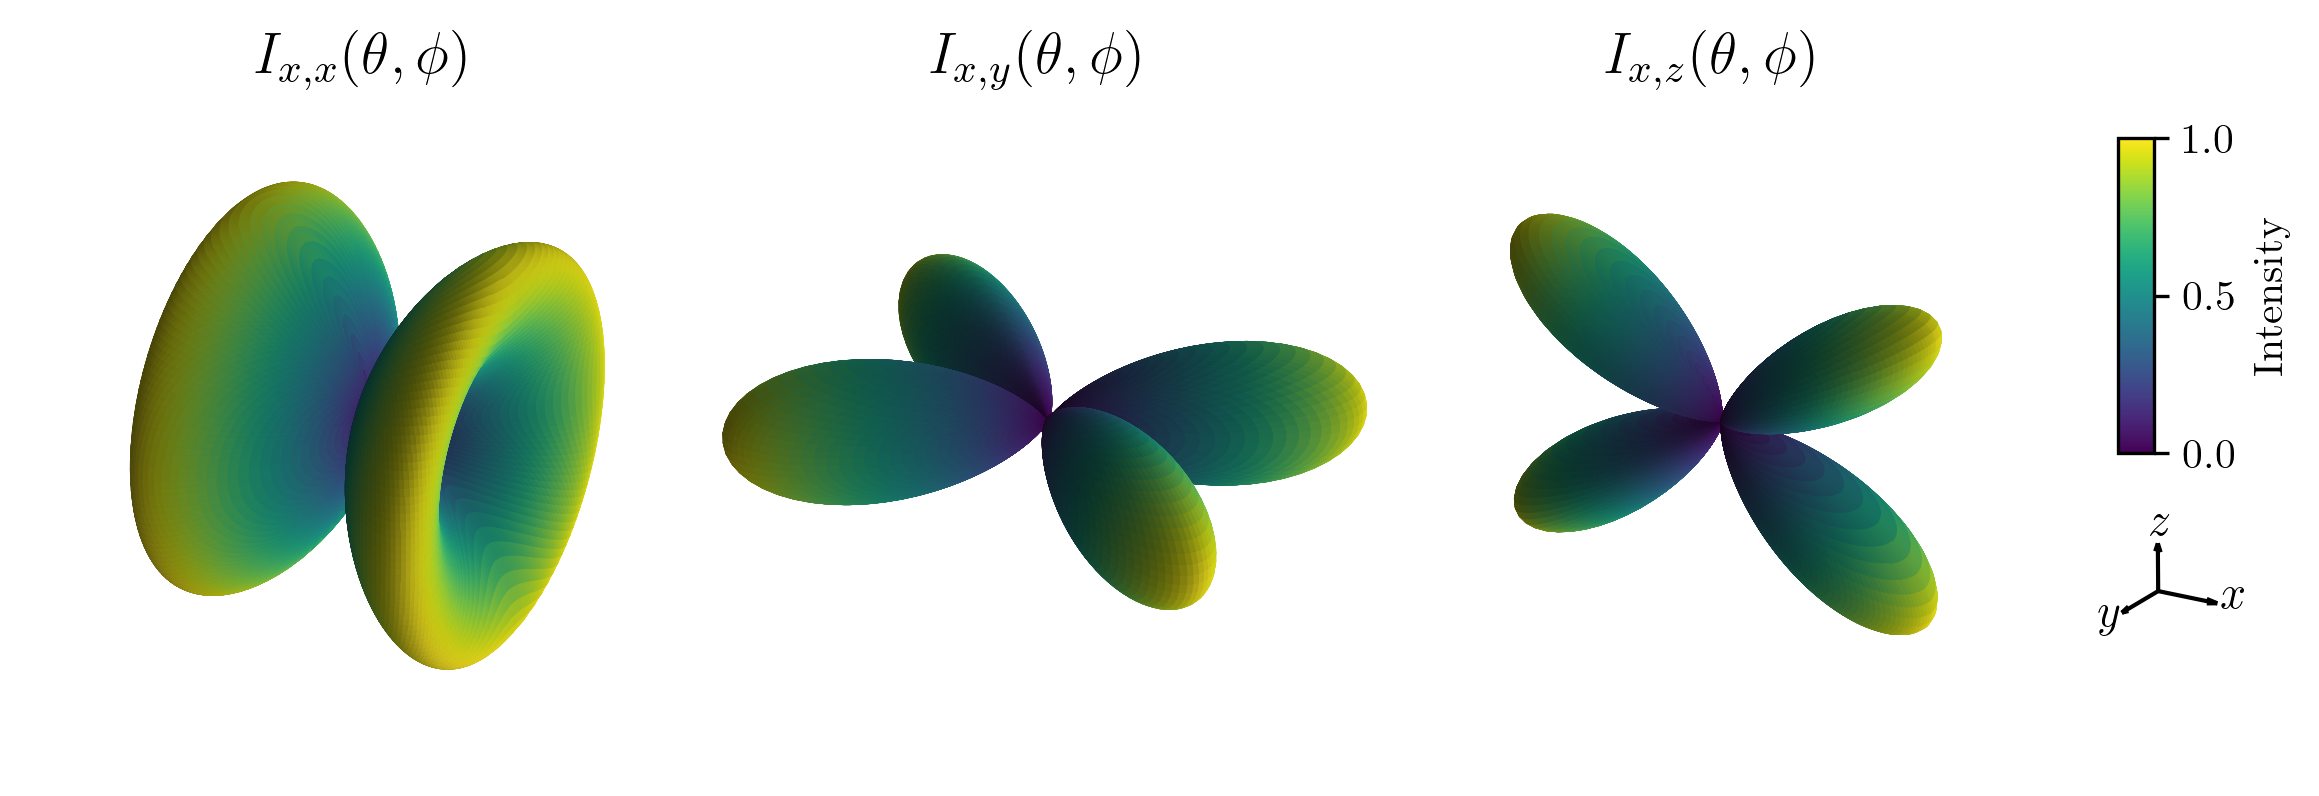

In [5]:
E_plus_x, E_minus_x, dE_x = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=0, 
                                                   disp_nm=DEFAULT_COM_DISPLACEMENT_NM, **farfield_params)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = info_patterns_from_scattered_field(dE=dE_x, delta_mu=DEFAULT_COM_DISPLACEMENT_NM, wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_x_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, scale_list=[0.4, 0.32, 0.36], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_x_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 365.5ms, inv.: 569.6ms, repropa.: 7.8ms (1 field configs), tot: 943.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 138.3ms, inv.: 331.7ms, repropa.: 20.5ms (1 field configs), tot: 491.9ms


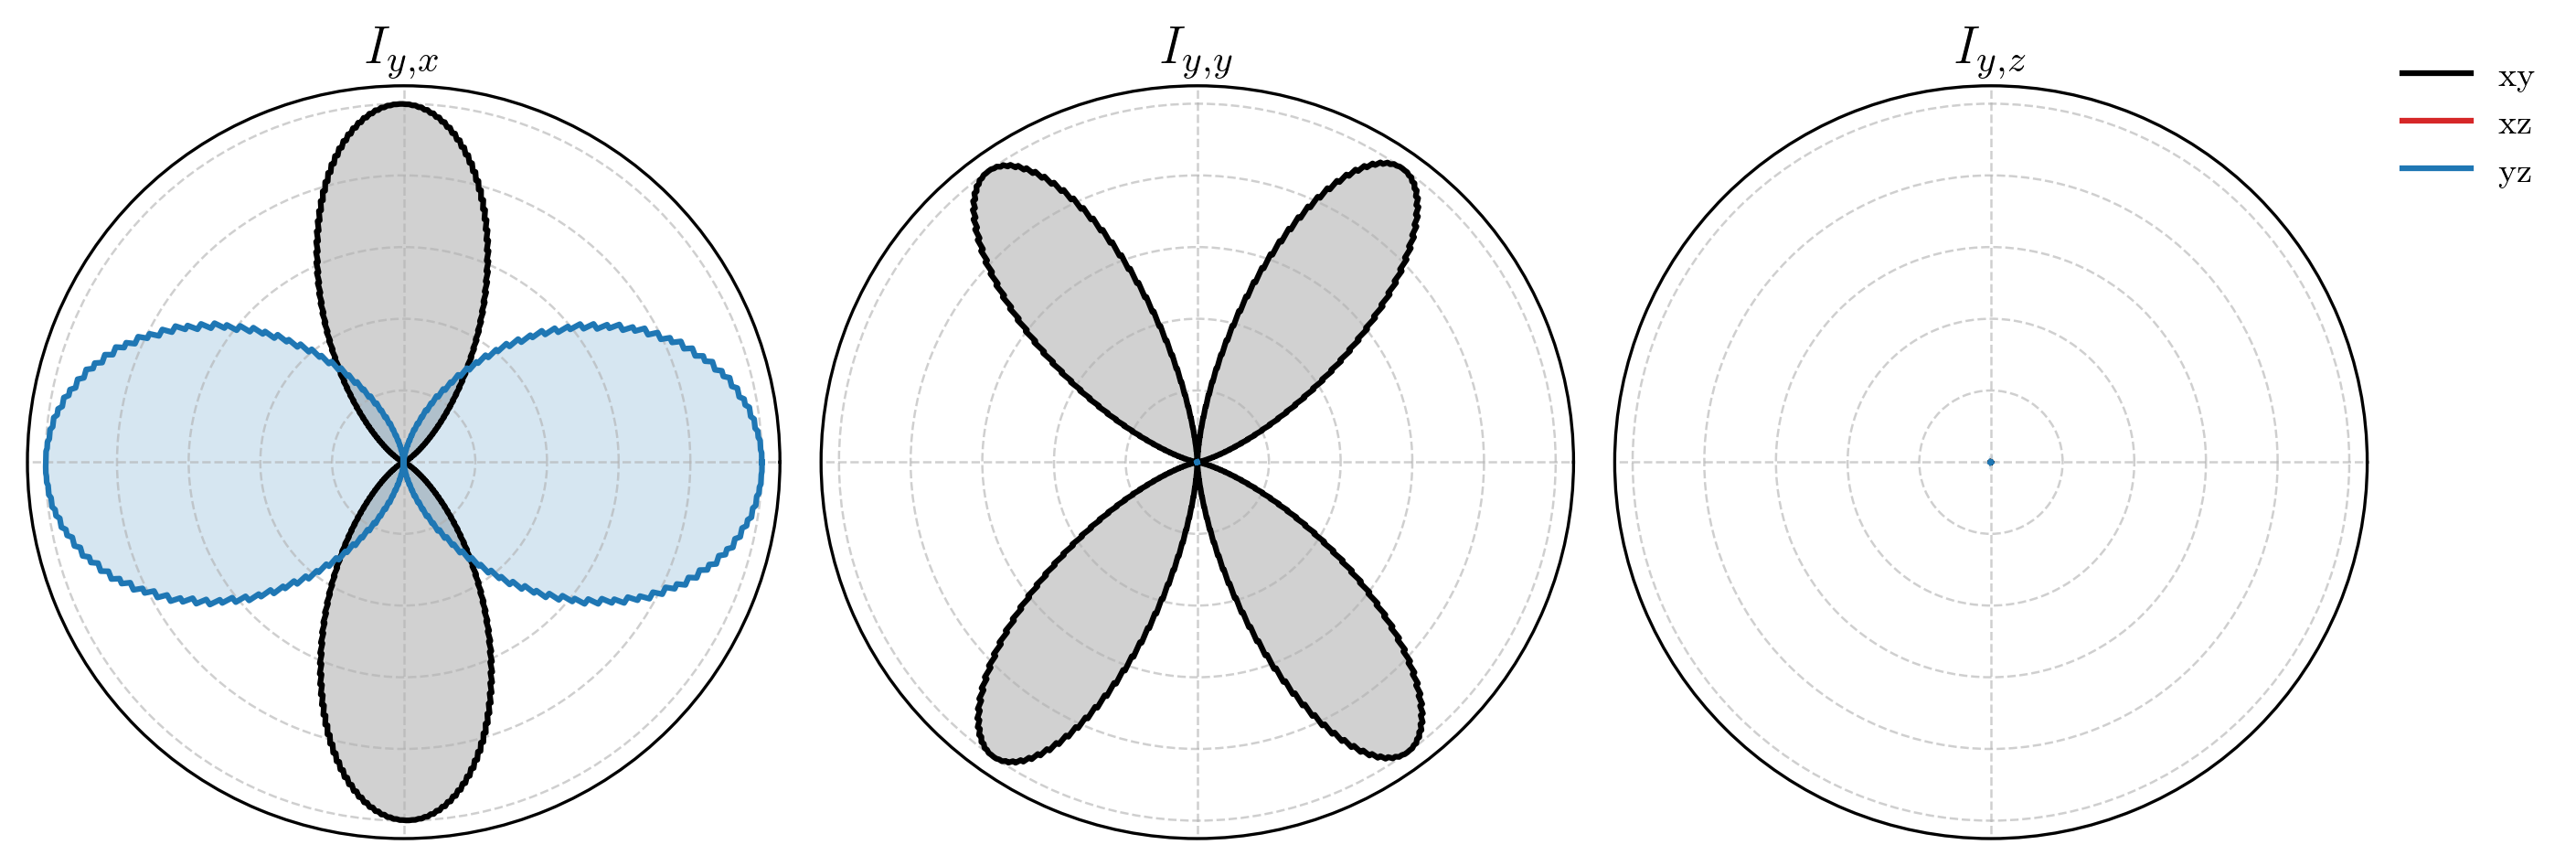

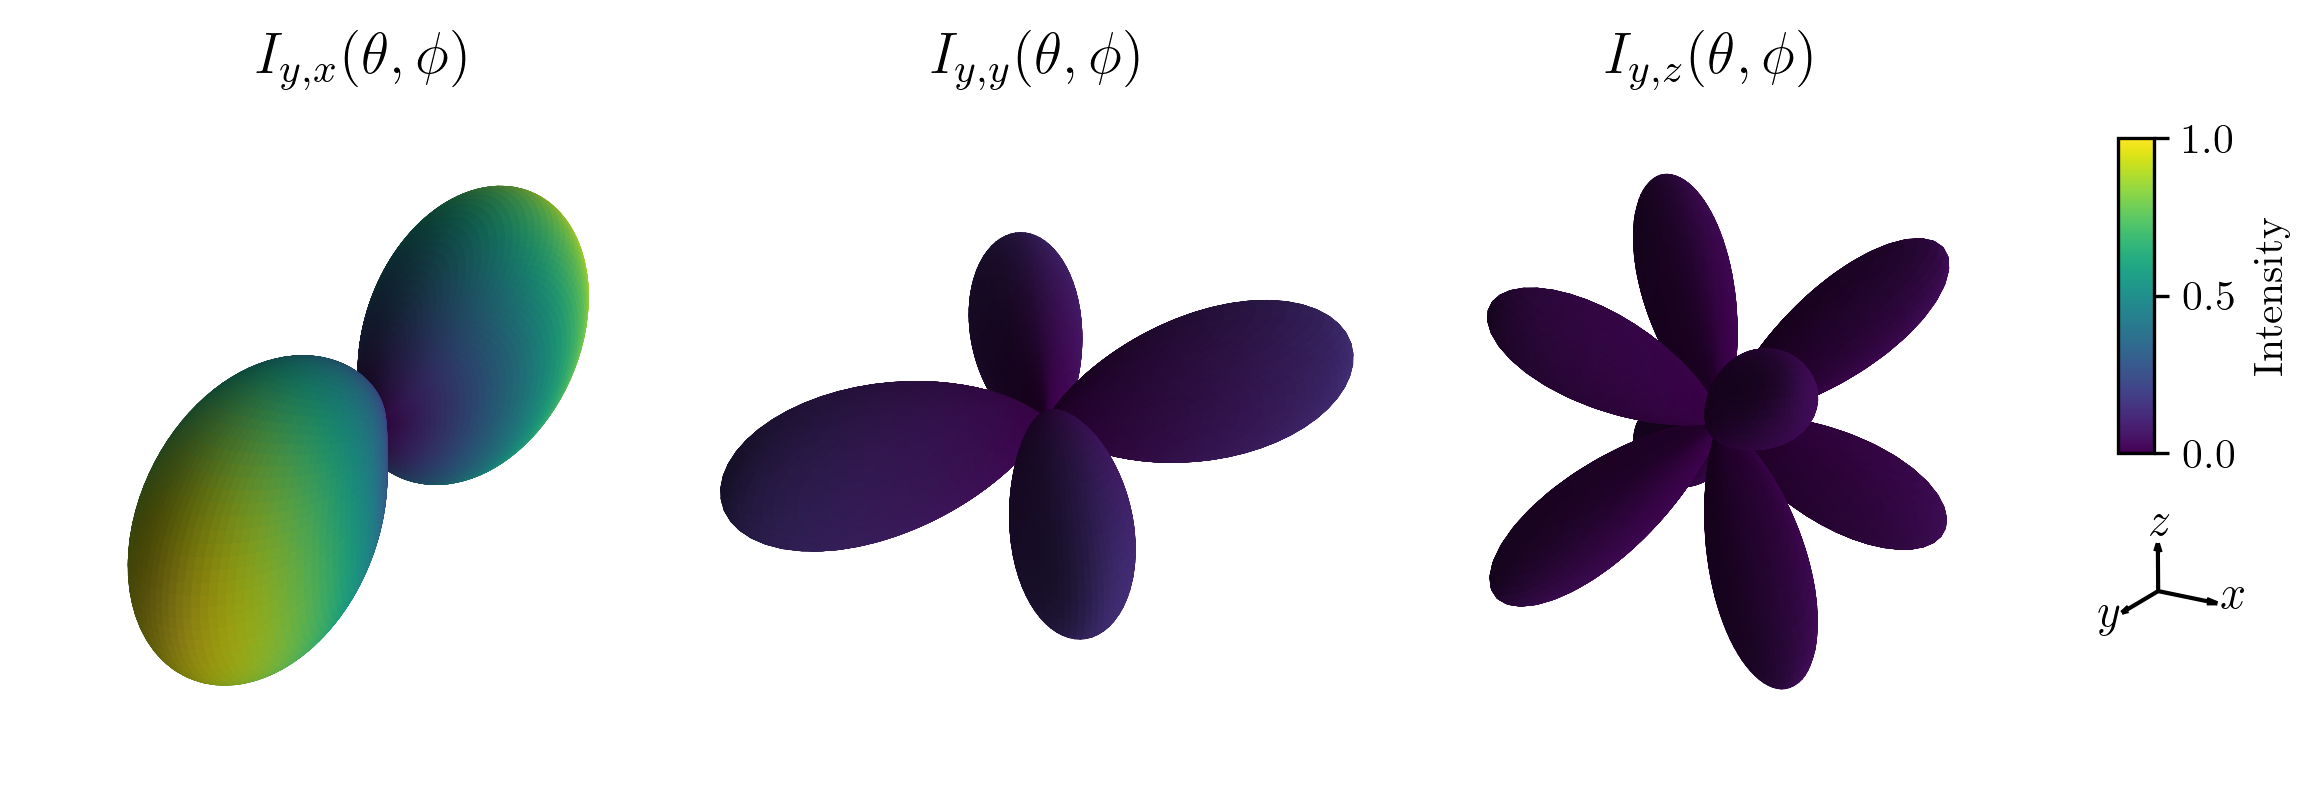

In [6]:
E_plus_y, E_minus_y, dE_y = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=1, 
                                                   disp_nm=DEFAULT_COM_DISPLACEMENT_NM, **farfield_params)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = info_patterns_from_scattered_field(dE=dE_y, delta_mu=DEFAULT_COM_DISPLACEMENT_NM, wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_y_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.22, 0.30, 0.48], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_y_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 54.7ms, inv.: 242.0ms, repropa.: 6.5ms (1 field configs), tot: 303.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 85.4ms, inv.: 248.0ms, repropa.: 15.0ms (1 field configs), tot: 349.6ms


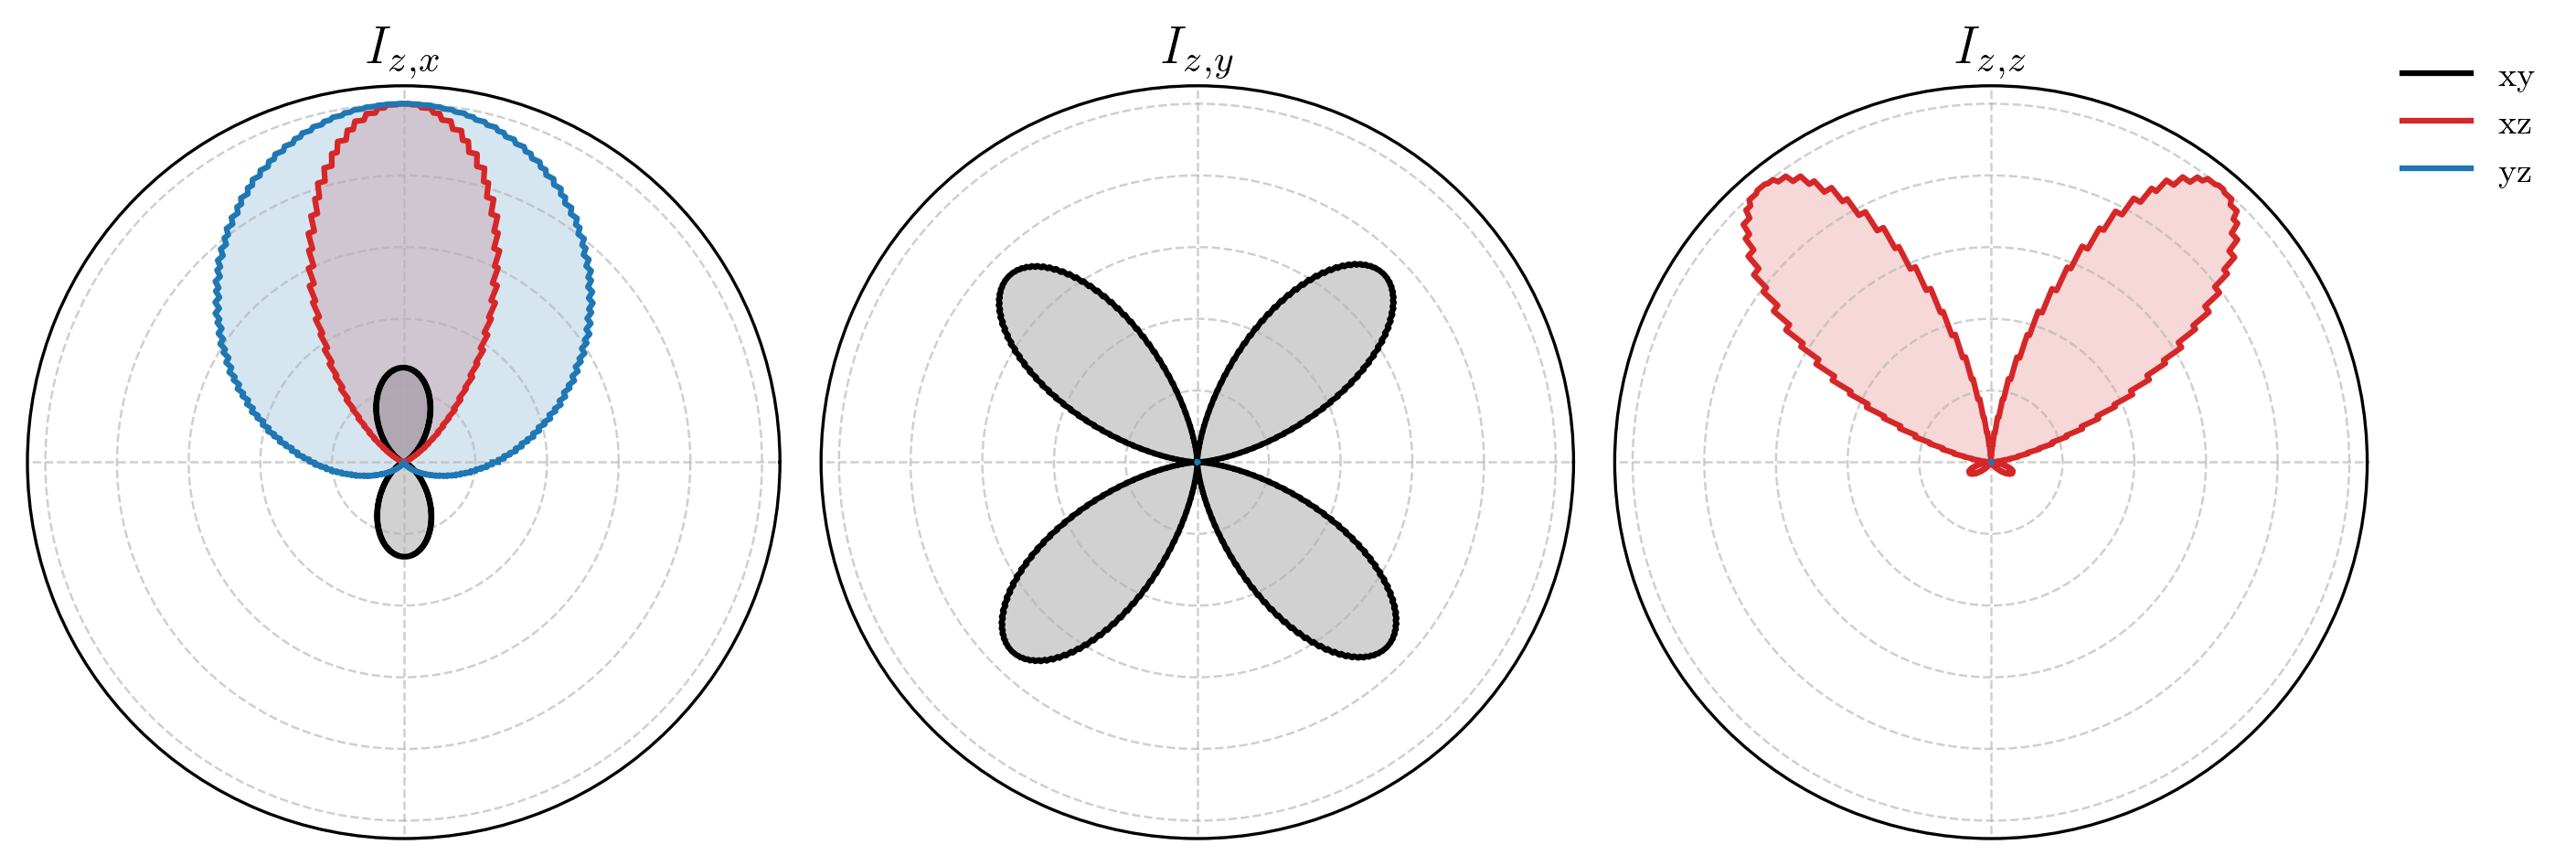

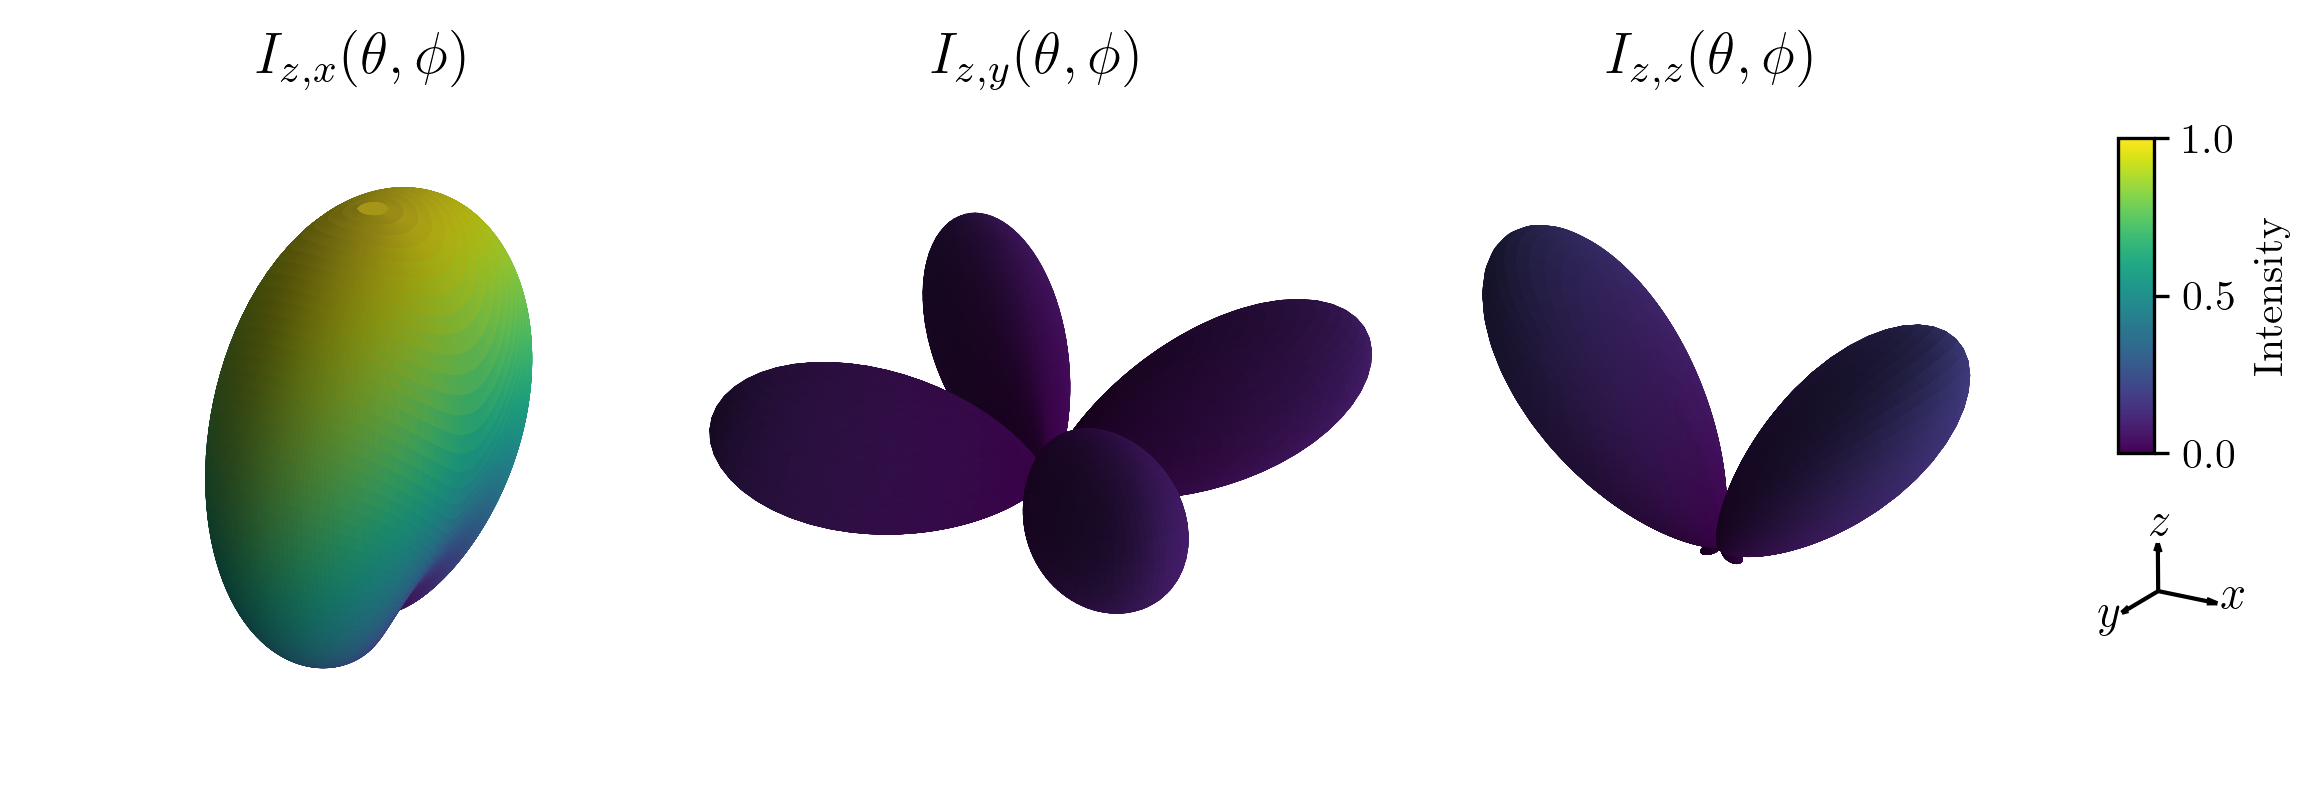

In [7]:
E_plus_z, E_minus_z, dE_z = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=2, 
                                                   disp_nm=DEFAULT_COM_DISPLACEMENT_NM, **farfield_params)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = info_patterns_from_scattered_field(dE=dE_z, delta_mu=DEFAULT_COM_DISPLACEMENT_NM, wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.36, 0.34, 0.33], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_z_3d", results_dir=results_dir)

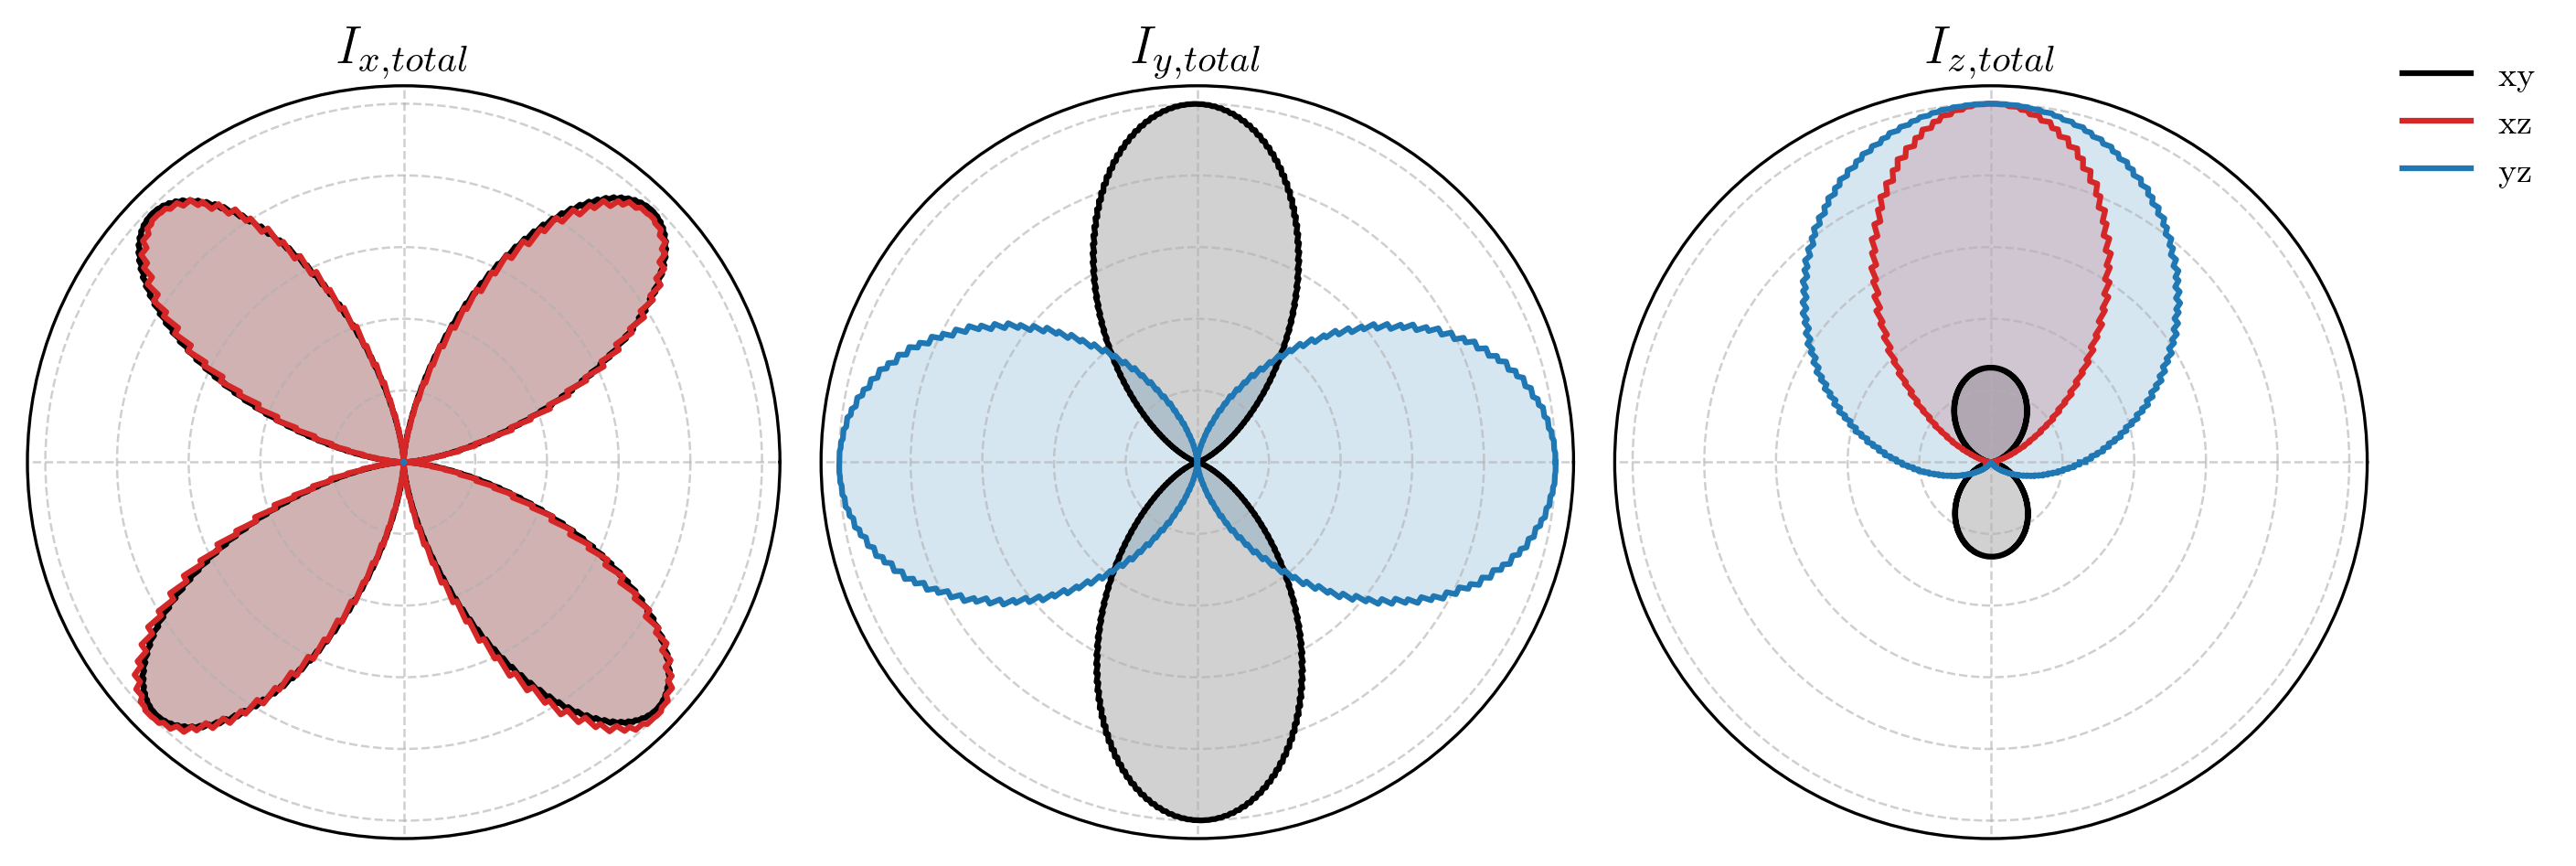

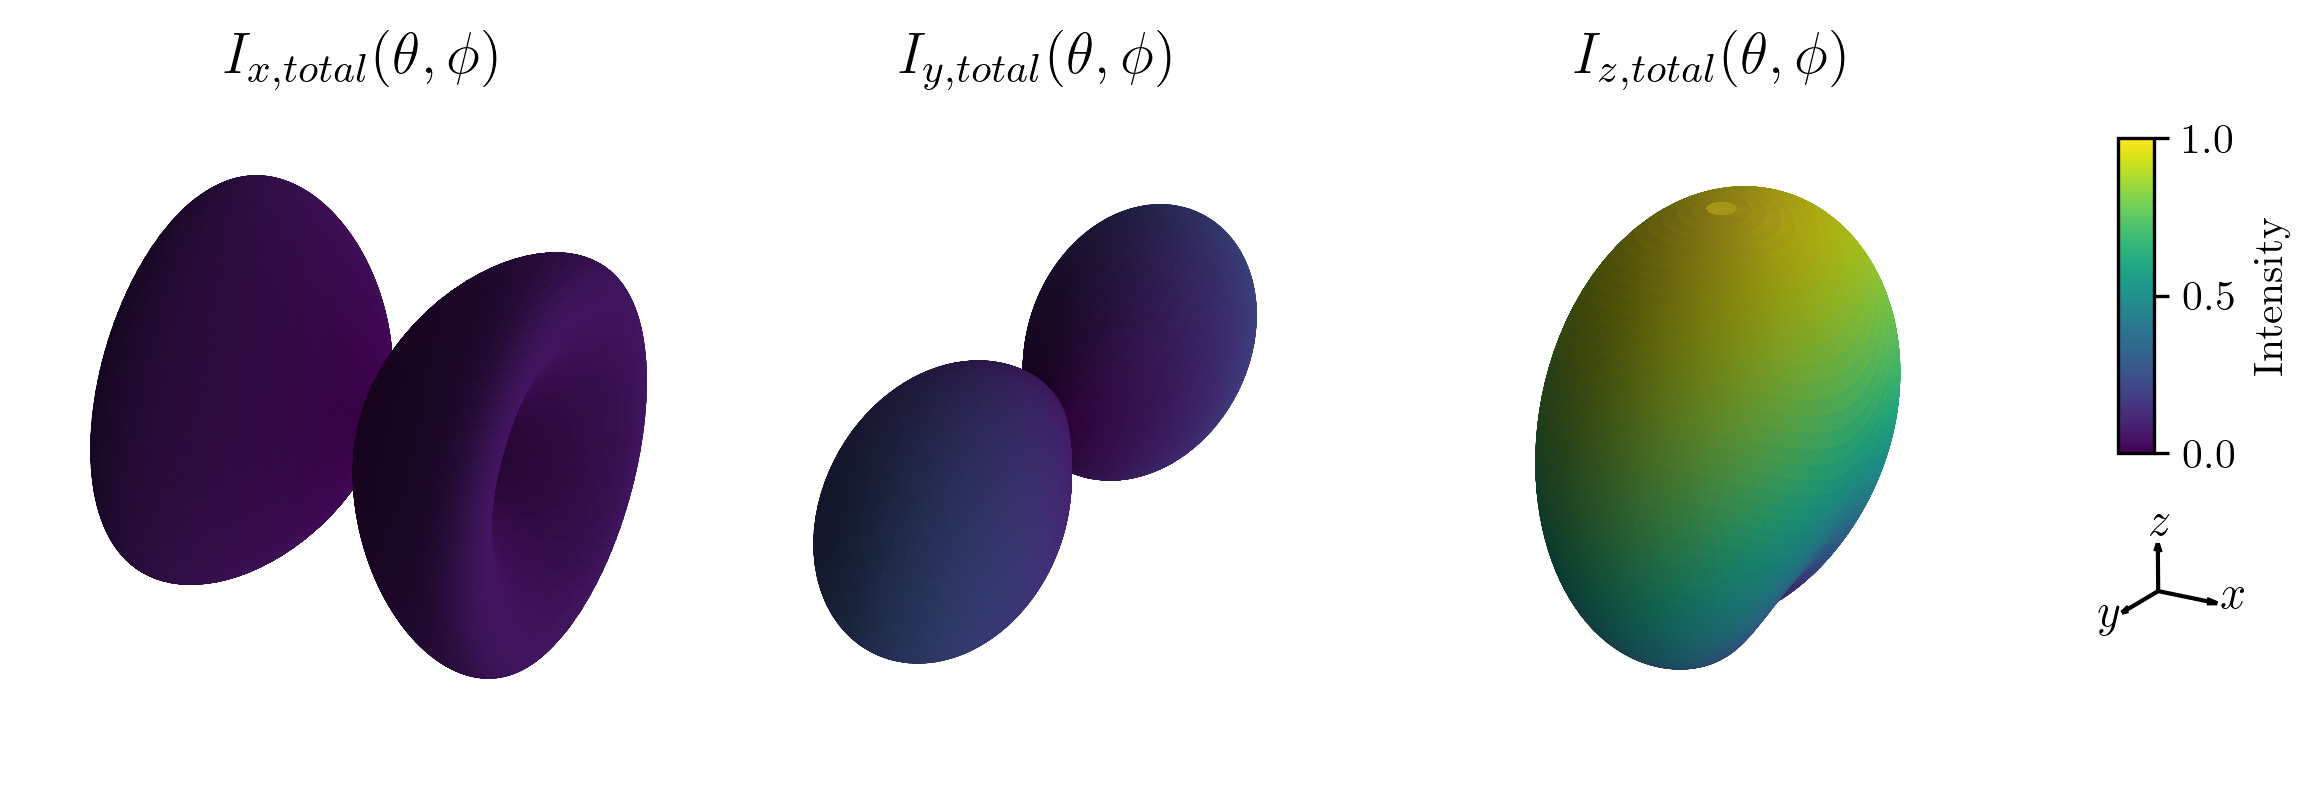

In [8]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_total_2d", 
                     results_dir=results_dir)

plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.24, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_total_3d", results_dir=results_dir)